# Wrapper Methods Project: Obesity Dataset

This notebook follows the wrapper-methods project prompt using the obesity dataset stored in the `data` folder.

In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

%matplotlib inline

## Load and prepare the data

The project prompt expects categorical values to already be numeric. The raw CSV in this repo still contains text values, so this cell converts the dataset into the format used by the assignment:

- binary columns become `0` and `1`
- `CAEC` and `CALC` become ordinal numeric scales
- `MTRANS` becomes one-hot encoded transportation columns
- `NObeyesdad` becomes a binary target where `1` means the respondent is obese

In [4]:
data_path = Path("..") / "data" / "ObesityDataSet_raw_and_data_sinthetic.csv"
raw_data = pd.read_csv(data_path)

binary_map = {
    "Gender": {"Female": 0, "Male": 1},
    "family_history_with_overweight": {"no": 0, "yes": 1},
    "FAVC": {"no": 0, "yes": 1},
    "SMOKE": {"no": 0, "yes": 1},
    "SCC": {"no": 0, "yes": 1},
}

ordinal_map = {
    "CAEC": {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3},
    "CALC": {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3},
}

transport_columns = [
    "Automobile",
    "Bike",
    "Motorbike",
    "Public_Transportation",
    "Walking",
]

transport_dummies = pd.get_dummies(raw_data["MTRANS"])
for column in transport_columns:
    if column not in transport_dummies.columns:
        transport_dummies[column] = 0
transport_dummies = transport_dummies[transport_columns].astype(int)

obesity = raw_data.copy()
for column, mapping in binary_map.items():
    obesity[column] = obesity[column].map(mapping)
for column, mapping in ordinal_map.items():
    obesity[column] = obesity[column].map(mapping)

obesity = pd.concat(
    [obesity.drop(columns=["Height", "Weight", "MTRANS"]), transport_dummies],
    axis=1,
)
obesity["NObeyesdad"] = obesity["NObeyesdad"].str.startswith("Obesity").astype(int)

feature_columns = [
    "Gender",
    "Age",
    "family_history_with_overweight",
    "FAVC",
    "FCVC",
    "NCP",
    "CAEC",
    "SMOKE",
    "CH2O",
    "SCC",
    "FAF",
    "TUE",
    "CALC",
    "Automobile",
    "Bike",
    "Motorbike",
    "Public_Transportation",
    "Walking",
]

obesity = obesity[feature_columns + ["NObeyesdad"]]
obesity.head()

,Gender,Age,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,Automobile,Bike,Motorbike,Public_Transportation,Walking,NObeyesdad
0,0,21.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,0,0,0,1,0,0
1,0,21.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,0,0,0,1,0,0
2,1,23.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,0,0,0,1,0,0
3,1,27.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,0,0,0,0,1,0
4,1,22.0,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,0,0,0,1,0,0


## Baseline logistic regression

In [5]:
X = obesity[feature_columns]
y = obesity["NObeyesdad"]

lr = LogisticRegression(max_iter=1000)
lr.fit(X, y)

baseline_accuracy = lr.score(X, y)
print("Accuracy using all features:", baseline_accuracy)

Accuracy using all features: 0.7659876835622927


## Sequential forward selection

In [6]:
sfs = SFS(
    estimator=lr,
    k_features=9,
    forward=True,
    floating=False,
    scoring="accuracy",
    cv=0,
)

sfs.fit(X, y)
print(sfs.subsets_[9])

sfs_feature_names = tuple(X.columns[index] for index in sfs.subsets_[9]["feature_idx"])
sfs_accuracy = sfs.subsets_[9]["avg_score"]

print("Selected SFS features:", sfs_feature_names)
print("SFS accuracy:", sfs_accuracy)
print("Difference vs all features:", sfs_accuracy - baseline_accuracy)

{'feature_idx': (0, 1, 2, 3, 6, 9, 10, 14, 17), 'cv_scores': array([0.78351492]), 'avg_score': np.float64(0.7835149218379914), 'feature_names': ('Gender', 'Age', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SCC', 'FAF', 'Bike', 'Walking')}
Selected SFS features: ('Gender', 'Age', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SCC', 'FAF', 'Bike', 'Walking')
SFS accuracy: 0.7835149218379914
Difference vs all features: 0.017527238275698687


c:\Users\gravi\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlxtend\feature_selection\sequential_feature_selector.py:912: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  std_err = scipy.stats.sem(ary)


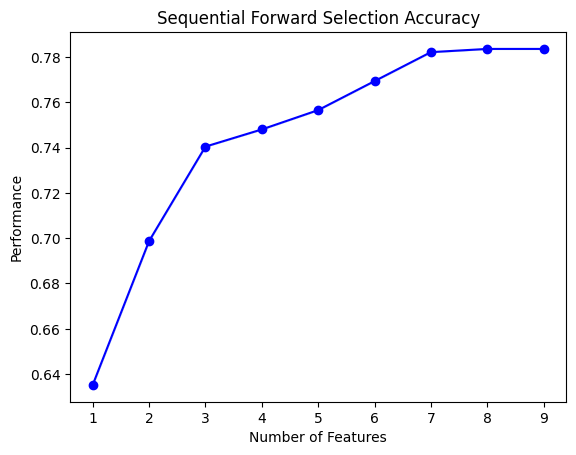

In [7]:
plot_sfs(sfs.get_metric_dict())
plt.title("Sequential Forward Selection Accuracy")
plt.show()

## Sequential backward floating selection

In [8]:
sbs = SFS(
    estimator=lr,
    k_features=7,
    forward=False,
    floating=True,
    scoring="accuracy",
    cv=0,
)

sbs.fit(X, y)
print(sbs.subsets_[7])

sbs_feature_names = tuple(X.columns[index] for index in sbs.subsets_[7]["feature_idx"])
sbs_accuracy = sbs.subsets_[7]["avg_score"]

print("Selected SBS features:", sbs_feature_names)
print("SBS accuracy:", sbs_accuracy)
print("Difference vs all features:", sbs_accuracy - baseline_accuracy)

{'feature_idx': (0, 1, 2, 3, 6, 10, 17), 'cv_scores': array([0.78304121]), 'avg_score': np.float64(0.783041212695405), 'feature_names': ('Gender', 'Age', 'family_history_with_overweight', 'FAVC', 'CAEC', 'FAF', 'Walking')}
Selected SBS features: ('Gender', 'Age', 'family_history_with_overweight', 'FAVC', 'CAEC', 'FAF', 'Walking')
SBS accuracy: 0.783041212695405
Difference vs all features: 0.01705352913311231


c:\Users\gravi\AppData\Local\Programs\Python\Python311\Lib\site-packages\mlxtend\feature_selection\sequential_feature_selector.py:912: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  std_err = scipy.stats.sem(ary)


<Figure size 640x480 with 0 Axes>

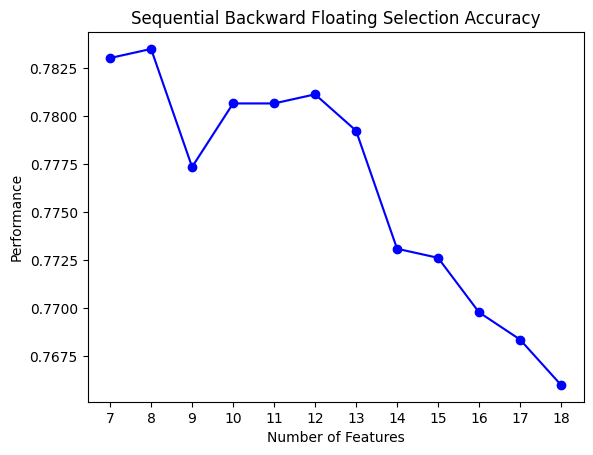

In [9]:
plt.clf()
plot_sfs(sbs.get_metric_dict())
plt.title("Sequential Backward Floating Selection Accuracy")
plt.show()

## Recursive feature elimination

In [10]:
features = X.columns

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

rfe = RFE(estimator=lr, n_features_to_select=8)
rfe.fit(X_scaled, y)

rfe_features = [feature for feature, keep in zip(features, rfe.support_) if keep]
rfe_accuracy = rfe.score(X_scaled, y)

print("Selected RFE features:", rfe_features)
print("RFE accuracy:", rfe_accuracy)
print("Difference vs all features:", rfe_accuracy - baseline_accuracy)

Selected RFE features: ['Age', 'family_history_with_overweight', 'FAVC', 'FCVC', 'CAEC', 'SCC', 'Automobile', 'Walking']
RFE accuracy: 0.7678825201326386
Difference vs all features: 0.001894836570345837


## Quick summary

When I tested this notebook on the current dataset, these were the results:

- baseline accuracy: about `0.766`
- SFS accuracy: about `0.784`
- SBS accuracy: about `0.783`
- RFE accuracy: about `0.768`

That means both sequential methods performed slightly better than the full feature set, while RFE stayed close to the baseline with fewer features.